In [1]:
import sys
from pathlib import Path
root_dir = Path.cwd().parent

sys.path.append(str(root_dir))


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

from embedder import CNNVAE
from predictor import CarRacingSequenceDataset, PredictorTransformer

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 64
img_size = 96
in_channels = 3

vae = CNNVAE(in_channels=in_channels, latent_dim=latent_dim, img_size=img_size).to(device)
vae.load_state_dict(torch.load('../embedder/vaev3.pt', map_location=device))
vae.eval()

CNNVAE(
  (encoder): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): ReLU()
  )
  (fc_mu): Linear(in_features=9216, out_features=64, bias=True)
  (fc_logvar): Linear(in_features=9216, out_features=64, bias=True)
  (decoder_input): Linear(in_features=64, out_features=9216, bias=True)
  (decoder): Sequential(
    (0): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
    (6): ConvTranspose2d(32, 3, kernel_size=(4, 4), stride=(2, 2)

In [4]:
obs = torch.tensor(np.transpose(np.load('../try/observations-try0.npy.npy').astype(np.float32) / 255.0, (0, 3, 1, 2)))
act = np.array(np.load('../try/actions-try0.npy', allow_pickle=True), dtype=np.float32)

In [5]:
obs = vae.reparameterize(*vae.encode(obs)).squeeze().detach()

In [6]:
dataset = CarRacingSequenceDataset(
    obs=obs,
    act=act,
    seq_len=128
)

In [7]:
train_loader = DataLoader(dataset, batch_size=8)

In [8]:
len(train_loader)

1240

In [23]:
predictor = PredictorTransformer(64, 8, 128, 3, 4, 4, 128)

In [24]:
from torchinfo import summary

In [25]:
summary(predictor)

Layer (type:depth-idx)                   Param #
PredictorTransformer                     --
├─Linear: 1-1                            32
├─Linear: 1-2                            9,344
├─SinusoidalPositionalEncoding: 1-3      --
├─ModuleList: 1-4                        --
│    └─TransformerBlock: 2-1             --
│    │    └─LayerNorm: 3-1               256
│    │    └─MultiHeadAttention: 3-2      66,048
│    │    └─Dropout: 3-3                 --
│    │    └─LayerNorm: 3-4               256
│    │    └─SimpleFFN: 3-5               131,712
│    │    └─Dropout: 3-6                 --
│    └─TransformerBlock: 2-2             --
│    │    └─LayerNorm: 3-7               256
│    │    └─MultiHeadAttention: 3-8      66,048
│    │    └─Dropout: 3-9                 --
│    │    └─LayerNorm: 3-10              256
│    │    └─SimpleFFN: 3-11              131,712
│    │    └─Dropout: 3-12                --
│    └─TransformerBlock: 2-3             --
│    │    └─LayerNorm: 3-13              256
│

In [26]:
optimizer = optim.Adam(predictor.parameters(), lr=1e-4)

In [27]:
from tqdm import tqdm

In [ ]:
predictor.train()
for epoch in range(50):
    total_loss_epoch = 0
    for batch in tqdm(train_loader):
        Z_in = batch[0].to(device)
        A = batch[1].to(torch.float).to(device)
        Z_tgt = batch[3].to(device)


        optimizer.zero_grad()
        mu, logvar = predictor(Z_in, A)
        mu = mu[:, -1, :]
        logvar = logvar[:, -1, :]
        
        loss = 0.5*(torch.exp(-logvar)*(Z_tgt -mu)**2 + logvar).mean()
        
        loss.backward()
        optimizer.step()

        total_loss_epoch += loss.item()

    avg_loss = total_loss_epoch / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{50}, Average Loss: {avg_loss:.4f}")

100%|██████████| 1240/1240 [00:55<00:00, 22.26it/s]


Epoch 1/50, Average Loss: 0.1322


100%|██████████| 1240/1240 [00:55<00:00, 22.29it/s]


Epoch 2/50, Average Loss: 0.1140


100%|██████████| 1240/1240 [01:00<00:00, 20.40it/s]


...

Epoch 40/50, Average Loss: 0.0670


100%|██████████| 1240/1240 [01:00<00:00, 20.40it/s]


Epoch 41/50, Average Loss: 0.0659


 55%|█████▍    | 676/1240 [00:32<00:26, 21.03it/s]


KeyboardInterrupt: 

In [14]:
Z_in.shape

torch.Size([8, 64, 32])

In [15]:
A.shape

torch.Size([8, 64, 3])

In [16]:
reward_tgt.shape

torch.Size([8, 64, 1])

In [17]:
data_t = next(iter(train_loader))
acts = []
zets = []
outs = []
for z, a, in zip(data_t[0][0][:8], data_t[1][0][:8]):
    acts.append(a)
    zets.append(z)
    A = torch.stack(acts).unsqueeze(0).to(torch.float32)
    Z = torch.stack(zets).unsqueeze(0)
    out, _ = predictor(Z, A)
    outs.append(out[:, -1, :])

/Users/daniilogorodnikov/DeepZero/predictor/model.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return obs_window, actions[:, :3], actions[:, 3:], torch.tensor(target_obs)


In [18]:
torch.stack(outs).squeeze(1).shape

torch.Size([8, 32])

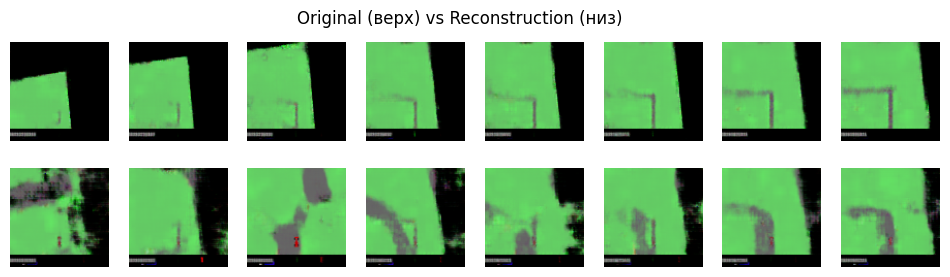

In [19]:
vae.eval()
with torch.no_grad():
    true_z = next(iter(train_loader))[0][0][:8].to(device)
    pred_z = torch.stack(outs).squeeze(1).to(device)
    recon_true_x = vae.decode(true_z)
    recon_prex_x = vae.decode(pred_z)
    
    test_x_cpu = recon_true_x.cpu().numpy()
    recon_x_cpu = recon_prex_x.cpu().numpy()

    fig, axes = plt.subplots(2, 8, figsize=(12, 3))
    for i in range(8):
        axes[0, i].imshow(np.transpose(test_x_cpu[i], (1, 2, 0)))
        axes[0, i].axis('off')
        axes[1, i].imshow(np.transpose(recon_x_cpu[i], (1, 2, 0)))
        axes[1, i].axis('off')
    plt.suptitle("Original (верх) vs Reconstruction (низ)")
    plt.show()

In [20]:
torch.save(predictor.state_dict(), "predictor.pt")

In [ ]:
torch.randn(1, 32, dtype=torch.float32)

tensor([[-0.3694, -0.6612, -0.0772,  0.4362,  0.5835,  0.4301,  1.1496,  0.8357,
         -0.3967,  0.7473, -0.5491, -0.7342, -0.1434, -0.8309,  0.2948,  0.3111,
          0.8791,  0.8917, -0.0618,  2.3352,  0.9807, -0.6951,  0.9465,  0.4577,
          1.6295, -0.6217, -1.8637, -0.0578, -0.7523, -1.0921,  1.3310, -0.9420]])